In [2]:
# Import all the libraries I need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Import functions from sklearn for building the model, training-testing split, visualising the model and metrics 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [3]:
# Load the dataset
df = pd.read_csv('data/Churn_Modelling.csv')

# Display the first few rows of the dataset
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# CustomerID, Surname, RowNumber are not useful for our analysis, so we will drop them
# I don't want to drop them yet because I want to see if they have any missing values or not

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
df['Gender'].unique() # There are only two unique values in the Gender column, so I can encode it as 0 and 1

array(['Female', 'Male'], dtype=object)

In [9]:
df['Geography'].unique() # There are three unique values in the Geography column, so I can encode it as 0, 1 and 2

array(['France', 'Spain', 'Germany'], dtype=object)

Unsupervise Machine Learning- Clusttering 

In [10]:
df = pd.get_dummies(df, columns=['Gender','Geography'], drop_first=True) # This will encode the Gender and Geography columns and drop the first category to avoid multicollinearity

In [11]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [12]:
# X = df.iloc[:, [3,6,7,8,9,10,11,12]]

In [13]:
# Define the features and the target variable

features = [
'CreditScore',      # 0
'Age',              # 1
'Tenure',           # 2
'Balance',          # 3
'NumOfProducts',    # 4
'HasCrCard',        # 5
'IsActiveMember',   # 6
'EstimatedSalary'   # 7
]


features_1 = [
'CreditScore',      # 0
'Age',              # 1
'Tenure',           # 2
'Balance'           # 3
]

# 'Geography_Germany',# 8
# 'Geography_Spain',  # 9
# 'Gender_Male'       # 10
X_features = df[features].values
X_features_1 = df[features_1].values


In [14]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df[features])

# When i scaled the X_features, the accuracy of the model dropped significantly, so I will not scale the features for now. 
# I will try scaling the features later and see if it improves the accuracy of the model.

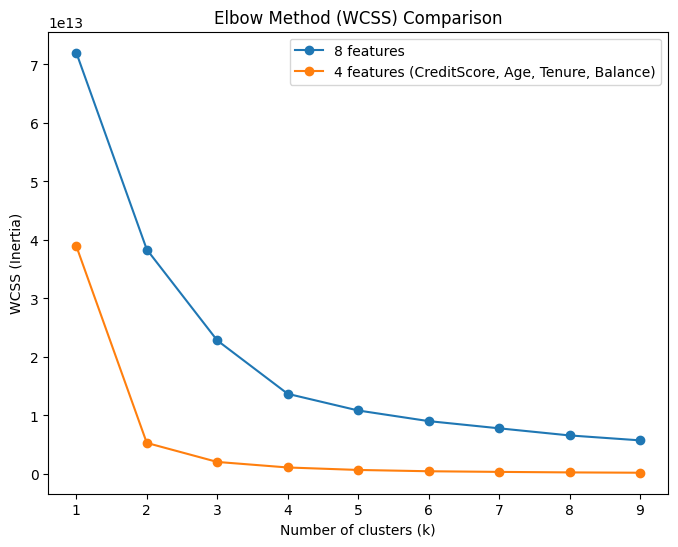

In [15]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the Elbow Method

wcss_full = []
wcss_small = []
K = range(1, 10)

for k in K:
    km_full = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km_full.fit(X_features)
    wcss_full.append(km_full.inertia_)

    km_small = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km_small.fit(X_features_1)
    wcss_small.append(km_small.inertia_)    




# Plot the Elbow Method graph

plt.figure(figsize=(8, 6))
plt.plot(K, wcss_full, marker='o', label='8 features')
plt.plot(K, wcss_small, marker='o', label='4 features (CreditScore, Age, Tenure, Balance)')
plt.title('Elbow Method (WCSS) Comparison')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()

plt.show()


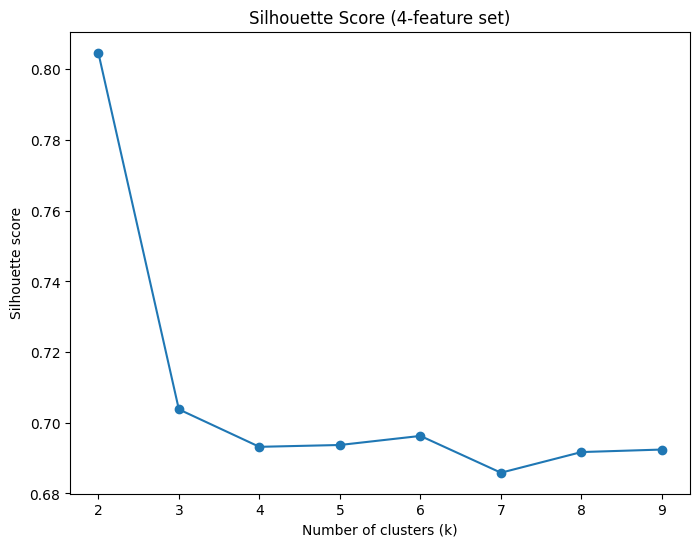

Best k by silhouette (4-feature set): 2


In [16]:
from sklearn import metrics


silh_small = []
K2 = range(2, 10)

for k in K2:
    km_small = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km_small.fit_predict(X_features_1)
    silh_small.append(metrics.silhouette_score(X_features_1, labels))

plt.figure(figsize=(8, 6))
plt.plot(K2, silh_small, marker='o')
plt.title('Silhouette Score (4-feature set)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.show()

best_k = K2[silh_small.index(max(silh_small))]
print("Best k by silhouette (4-feature set):", best_k)

In [17]:
# From the Elbow Method graph, we can see that the optimal number of clusters is 4, because the WCSS starts to decrease significantly after 4 clusters.
# Training the KMeans model with the optimal number of clusters
# The value of the dependent variable(X_features)will be cluster 1, cluster 2, cluster 3 and cluster 4
# Eaach the cluster will be a certain type of customer, for example, cluster 1 could be high-value customers, cluster 2 could be low-value customers, cluster 3 could be customers with high churn risk and cluster 4 could be customers with low churn risk.

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_features)

kmeans2 = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_kmeans_2 = kmeans2.fit_predict(X_features_1)


print(y_kmeans) # This will print the cluster labels for each customer in the dataset, which will be 0, 1, 2 or 3 depending on which cluster they belong to.
print(y_kmeans_2)

[3 0 0 ... 1 2 2]
[1 0 0 ... 1 0 0]


In [18]:
print(X_features.shape, X_features_1.shape)
print(kmeans.cluster_centers_.shape)

(10000, 8) (10000, 4)
(4, 8)


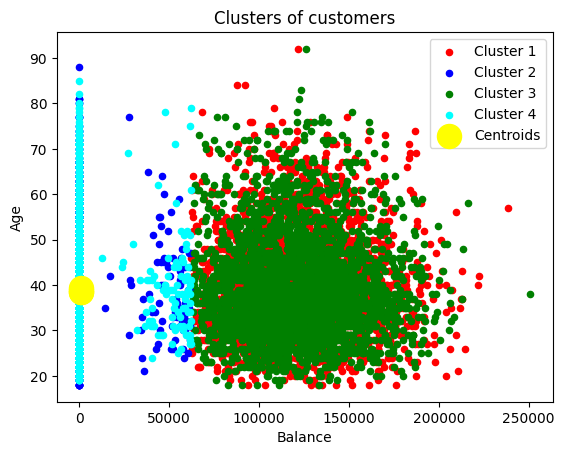

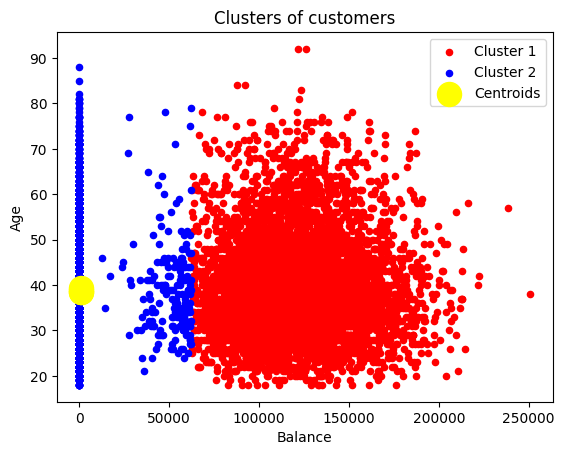

In [19]:
# Visualising the clusters using a scatter plot of two features, for example, Age and Balance 
X_plot = df[['Balance','Age']].values
plt.scatter(X_plot[y_kmeans == 0, 0], X_plot[y_kmeans == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
plt.scatter(X_plot[y_kmeans == 1, 0], X_plot[y_kmeans == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')
plt.scatter(X_plot[y_kmeans == 2, 0], X_plot[y_kmeans == 2, 1], s = 20, c = 'green', label = 'Cluster 3')
plt.scatter(X_plot[y_kmeans == 3, 0], X_plot[y_kmeans == 3, 1], s = 20, c = 'cyan', label = 'Cluster 4')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Balance')
plt.ylabel('Age')
plt.legend()
plt.show()

X_plot_2 = df[['Balance','Age']].values
plt.scatter(X_plot_2[y_kmeans_2 == 0, 0], X_plot_2[y_kmeans_2 == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
plt.scatter(X_plot_2[y_kmeans_2 == 1, 0], X_plot_2[y_kmeans_2 == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Balance')
plt.ylabel('Age')
plt.legend()
plt.show()

In [20]:
# This visualization shows the relationship between customer demographics (Age) and financial value (Balance). 


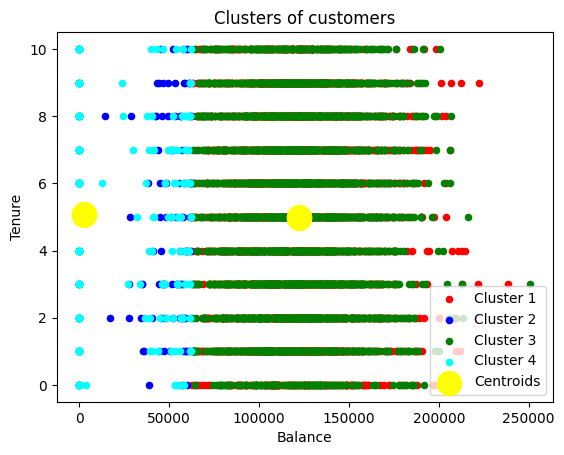

In [21]:
X_plot = df[['Balance','Tenure']].values

plt.scatter(X_plot[y_kmeans == 0, 0], X_plot[y_kmeans == 0, 1], s=20, c='red', label='Cluster 1')
plt.scatter(X_plot[y_kmeans == 1, 0], X_plot[y_kmeans == 1, 1], s=20, c='blue', label='Cluster 2')
plt.scatter(X_plot[y_kmeans == 2, 0], X_plot[y_kmeans == 2, 1], s=20, c='green', label='Cluster 3')
plt.scatter(X_plot[y_kmeans == 3, 0], X_plot[y_kmeans == 3, 1], s=20, c='cyan', label='Cluster 4')

plt.scatter(
kmeans.cluster_centers_[:,3],
kmeans.cluster_centers_[:,2],
s=300,
c='yellow',
label='Centroids'
)

plt.title('Clusters of customers')
plt.xlabel('Balance')
plt.ylabel('Tenure')
plt.legend()
plt.show()

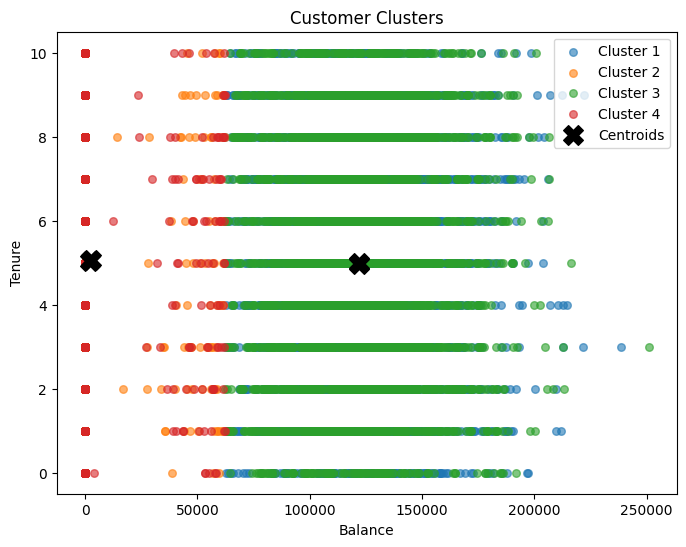

In [22]:
plt.figure(figsize=(8,6))

for i in range(4):
    plt.scatter(
        X_plot[y_kmeans == i,0],
        X_plot[y_kmeans == i,1],
        s=30,
        alpha=0.6,
        label=f"Cluster {i+1}"
    )

plt.scatter(
    kmeans.cluster_centers_[:,3],
    kmeans.cluster_centers_[:,2],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Clusters")
plt.xlabel("Balance")
plt.ylabel("Tenure")
plt.legend()
plt.show()

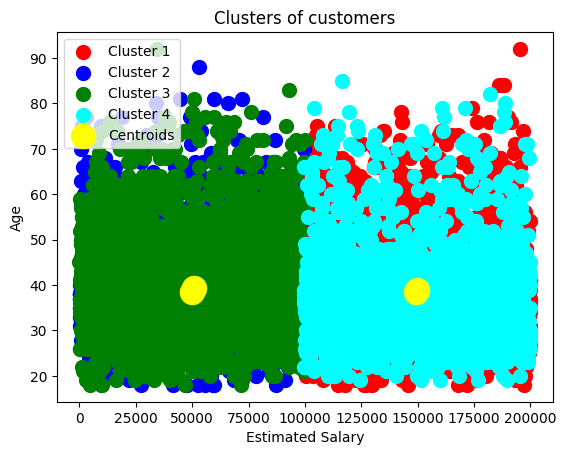

In [23]:
X_plot = df[['EstimatedSalary','Age']].values
# bal_i = features_2.index('Balance')
# age_i = features_2.index('Age')

plt.scatter(X_plot[y_kmeans == 0, 0], X_plot[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_plot[y_kmeans == 1, 0], X_plot[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_plot[y_kmeans == 2, 0], X_plot[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X_plot[y_kmeans == 3, 0], X_plot[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')

plt.scatter(
kmeans.cluster_centers_[:,7],
    kmeans.cluster_centers_[:,1],
    s=300, c='yellow', label='Centroids'

)

plt.title('Clusters of customers')
plt.xlabel('Estimated Salary')
plt.ylabel('Age')
plt.legend()
plt.show()

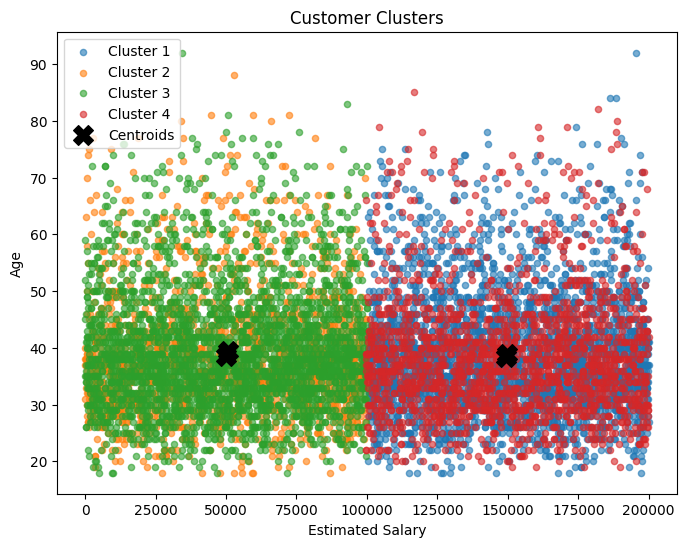

In [24]:
plt.figure(figsize=(8,6))

for i in range(4):
    plt.scatter(
        X_plot[y_kmeans == i, 0],
        X_plot[y_kmeans == i, 1],
        s=20,
        alpha=0.6,
        label=f"Cluster {i+1}"
    )

plt.scatter(
    kmeans.cluster_centers_[:,7],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Clusters")
plt.xlabel("Estimated Salary")
plt.ylabel("Age")
plt.legend()
plt.show()

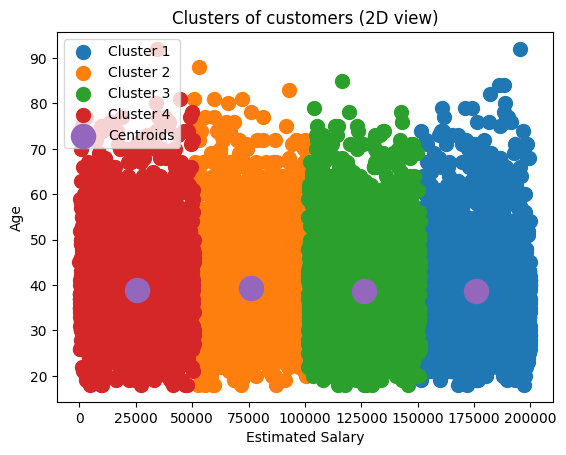

In [25]:

X_plot = df[['EstimatedSalary','Age']].values

kmeans_2d = KMeans(n_clusters=4, random_state=42)
y_2d = kmeans_2d.fit_predict(X_plot)

plt.scatter(X_plot[y_2d==0,0], X_plot[y_2d==0,1], s=100, label="Cluster 1")
plt.scatter(X_plot[y_2d==1,0], X_plot[y_2d==1,1], s=100, label="Cluster 2")
plt.scatter(X_plot[y_2d==2,0], X_plot[y_2d==2,1], s=100, label="Cluster 3")
plt.scatter(X_plot[y_2d==3,0], X_plot[y_2d==3,1], s=100, label="Cluster 4")

plt.scatter(kmeans_2d.cluster_centers_[:,0], kmeans_2d.cluster_centers_[:,1], s=300, label="Centroids")

plt.xlabel("Estimated Salary")
plt.ylabel("Age")
plt.title("Clusters of customers (2D view)")
plt.legend()
plt.show()

In [26]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_features)

# plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='viridis')
# plt.title("Customer Clusters (PCA)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.show()

In [27]:
# PCA is a dimensionality reduction technique that can help visualize high-dimensional data in 2D or 3D. However, it may not always capture the true cluster structure, especially if the clusters are not linearly separable. In this case, the PCA plot may show some separation between clusters, but it may not be as clear as the scatter plots of the original features.
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Use the 4-feature set you already have
X = X_features_1

# (Recommended) scale for DBSCAN
X_scaled = StandardScaler().fit_transform(X)

rows = []

# eps range: for scaled data, try small values
eps_values = np.arange(0.2, 3.1, 0.2)
min_samples_values = range(2, 10)

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(X_scaled)

        # number of clusters excluding noise (-1)
        unique = set(labels)
        n_clusters = len(unique) - (1 if -1 in unique else 0)
        n_noise = int((labels == -1).sum())

        # silhouette only valid if >= 2 clusters
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan

        rows.append({
            "Silhouette Score": sil,
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_ratio": n_noise / len(labels),
            "eps and min_samples": f"Eps: {eps}, Min Samples: {ms}"
        })

param_df = pd.DataFrame(rows)

# Show best settings (filter out NaNs + too-much-noise solutions)
best = (param_df
        .query("n_clusters >= 2 and noise_ratio < 0.5")
        .sort_values("Silhouette Score", ascending=False)
        .head(10))

best

,Silhouette Score,eps,min_samples,n_clusters,n_noise,noise_ratio,eps and min_samples
48,0.472776,1.4,2,2,1,0.0001,"Eps: 1.4000000000000001, Min Samples: 2"
40,0.468194,1.2,2,2,2,0.0002,"Eps: 1.2, Min Samples: 2"
32,0.430972,1.0,2,2,3,0.0003,"Eps: 1.0, Min Samples: 2"
20,0.256851,0.6,6,3,188,0.0188,"Eps: 0.6000000000000001, Min Samples: 6"
21,0.249864,0.6,7,2,230,0.0230,"Eps: 0.6000000000000001, Min Samples: 7"
17,0.223806,0.6,3,5,108,0.0108,"Eps: 0.6000000000000001, Min Samples: 3"
18,0.212509,0.6,4,3,130,0.0130,"Eps: 0.6000000000000001, Min Samples: 4"
19,0.211850,0.6,5,3,160,0.0160,"Eps: 0.6000000000000001, Min Samples: 5"
24,0.174682,0.8,2,4,15,0.0015,"Eps: 0.8, Min Samples: 2"
22,0.133625,0.6,8,3,269,0.0269,"Eps: 0.6000000000000001, Min Samples: 8"
